In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/SDS/'

Mounted at /content/drive


# Revisar Datos de entrenamiento

In [2]:
X_train = np.load(f'{DRIVE_PATH}X_train_final.npy')
X_test  = np.load(f'{DRIVE_PATH}X_test_final.npy')
y_train = np.load(f'{DRIVE_PATH}y_train.npy')
y_test  = np.load(f'{DRIVE_PATH}y_test.npy')
features_finales = np.load(f'{DRIVE_PATH}features_finales.npy', allow_pickle=True)

with open(f'{DRIVE_PATH}label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')
print(f'Features: {len(features_finales)}')
print(f'Clases: {len(le.classes_)}')

X_train: (992039, 37)
X_test:  (248010, 37)
y_train: (992336,)
y_test:  (248084,)
Features: 37
Clases: 34


In [3]:
y_train = y_train[:X_train.shape[0]]
y_test  = y_test[:X_test.shape[0]]

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (992039, 37)
X_test:  (248010, 37)
y_train: (992039,)
y_test:  (248010,)


# Entrenar Modelo

In [5]:
X_train_sel = np.load(f'{DRIVE_PATH}X_train_sel.npy')
X_test_sel  = np.load(f'{DRIVE_PATH}X_test_sel.npy')

print(f'X_train_sel: {X_train_sel.shape}')
print(f'X_test_sel:  {X_test_sel.shape}')
print(f'y_train:     {y_train.shape}')
print(f'y_test:      {y_test.shape}')

X_train_sel: (992336, 34)
X_test_sel:  (248084, 34)
y_train:     (992336,)
y_test:      (248084,)


In [6]:
y_train = np.load(f'{DRIVE_PATH}y_train.npy')
y_test  = np.load(f'{DRIVE_PATH}y_test.npy')

print(f'X_train_sel: {X_train_sel.shape}')
print(f'X_test_sel:  {X_test_sel.shape}')
print(f'y_train:     {y_train.shape}')
print(f'y_test:      {y_test.shape}')

X_train_sel: (992336, 34)
X_test_sel:  (248084, 34)
y_train:     (992336,)
y_test:      (248084,)


In [7]:
print('Iniciando entrenamiento RF con datos alineados...')
start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    verbose=2,
    class_weight='balanced'
)

rf.fit(X_train_sel, y_train)

elapsed = time.time() - start
print(f'Entrenamiento completado en {elapsed/60:.2f} minutos')

Iniciando entrenamiento RF con datos alineados...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100building tree 2 of 100

building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  1.4min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.7min finished


In [8]:
y_pred = rf.predict(X_test_sel)
print(classification_report(y_test, y_pred, target_names=le.classes_))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    3.4s


                         precision    recall  f1-score   support

       Backdoor_Malware       0.80      1.00      0.89       200
          BenignTraffic       0.94      0.89      0.91      9388
       BrowserHijacking       0.64      0.98      0.78       200
       CommandInjection       0.71      0.99      0.83       200
 DDoS-ACK_Fragmentation       0.99      0.99      0.99      2478
        DDoS-HTTP_Flood       0.95      0.96      0.96       248
        DDoS-ICMP_Flood       1.00      1.00      1.00     20000
DDoS-ICMP_Fragmentation       1.00      0.99      1.00      3832
      DDoS-PSHACK_Flood       1.00      1.00      1.00     20000
       DDoS-RSTFINFlood       1.00      1.00      1.00     20000
         DDoS-SYN_Flood       1.00      1.00      1.00     20000
         DDoS-SlowLoris       0.68      1.00      0.81       210
DDoS-SynonymousIP_Flood       1.00      1.00      1.00     20000
         DDoS-TCP_Flood       1.00      1.00      1.00     20000
         DDoS-UDP_Flood 

[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    6.7s finished


In [9]:
with open(f'{DRIVE_PATH}rf_final.pkl', 'wb') as f:
    pickle.dump(rf, f)

print('Modelo final guardado en Drive')

Modelo final guardado en Drive


# Refinamiento

In [10]:
from sklearn.model_selection import RandomizedSearchCV

X_sample = X_train_sel[:100000]
y_sample = y_train[:100000]

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')

search = RandomizedSearchCV(
    rf_search,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

print('Iniciando RandomizedSearchCV...')
start = time.time()
search.fit(X_sample, y_sample)
elapsed = time.time() - start

print(f'Search completado en {elapsed/60:.2f} minutos')
print(f'Mejores hiperparametros: {search.best_params_}')
print(f'Mejor F1 macro: {search.best_score_:.4f}')

Iniciando RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Search completado en 6.34 minutos
Mejores hiperparametros: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Mejor F1 macro: 0.8110


In [11]:
print('Iniciando entrenamiento RF refinado...')
start = time.time()

rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=1,
    max_features='log2',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    class_weight='balanced'
)

rf_final.fit(X_train_sel, y_train)

elapsed = time.time() - start
print(f'Entrenamiento completado en {elapsed/60:.2f} minutos')

Iniciando entrenamiento RF refinado...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  1.4min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.8min finished


In [12]:
y_pred_final = rf_final.predict(X_test_sel)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    3.4s


                         precision    recall  f1-score   support

       Backdoor_Malware       0.90      1.00      0.95       200
          BenignTraffic       0.92      0.92      0.92      9388
       BrowserHijacking       0.85      0.98      0.91       200
       CommandInjection       0.79      0.99      0.88       200
 DDoS-ACK_Fragmentation       0.99      0.99      0.99      2478
        DDoS-HTTP_Flood       0.99      0.96      0.98       248
        DDoS-ICMP_Flood       1.00      1.00      1.00     20000
DDoS-ICMP_Fragmentation       0.99      1.00      0.99      3832
      DDoS-PSHACK_Flood       1.00      1.00      1.00     20000
       DDoS-RSTFINFlood       1.00      1.00      1.00     20000
         DDoS-SYN_Flood       1.00      1.00      1.00     20000
         DDoS-SlowLoris       0.76      1.00      0.86       210
DDoS-SynonymousIP_Flood       1.00      1.00      1.00     20000
         DDoS-TCP_Flood       1.00      1.00      1.00     20000
         DDoS-UDP_Flood 

[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    8.5s finished


In [13]:
with open(f'{DRIVE_PATH}rf_final.pkl', 'wb') as f:
    pickle.dump(rf_final, f)

print('Modelo final guardado en Drive')

Modelo final guardado en Drive


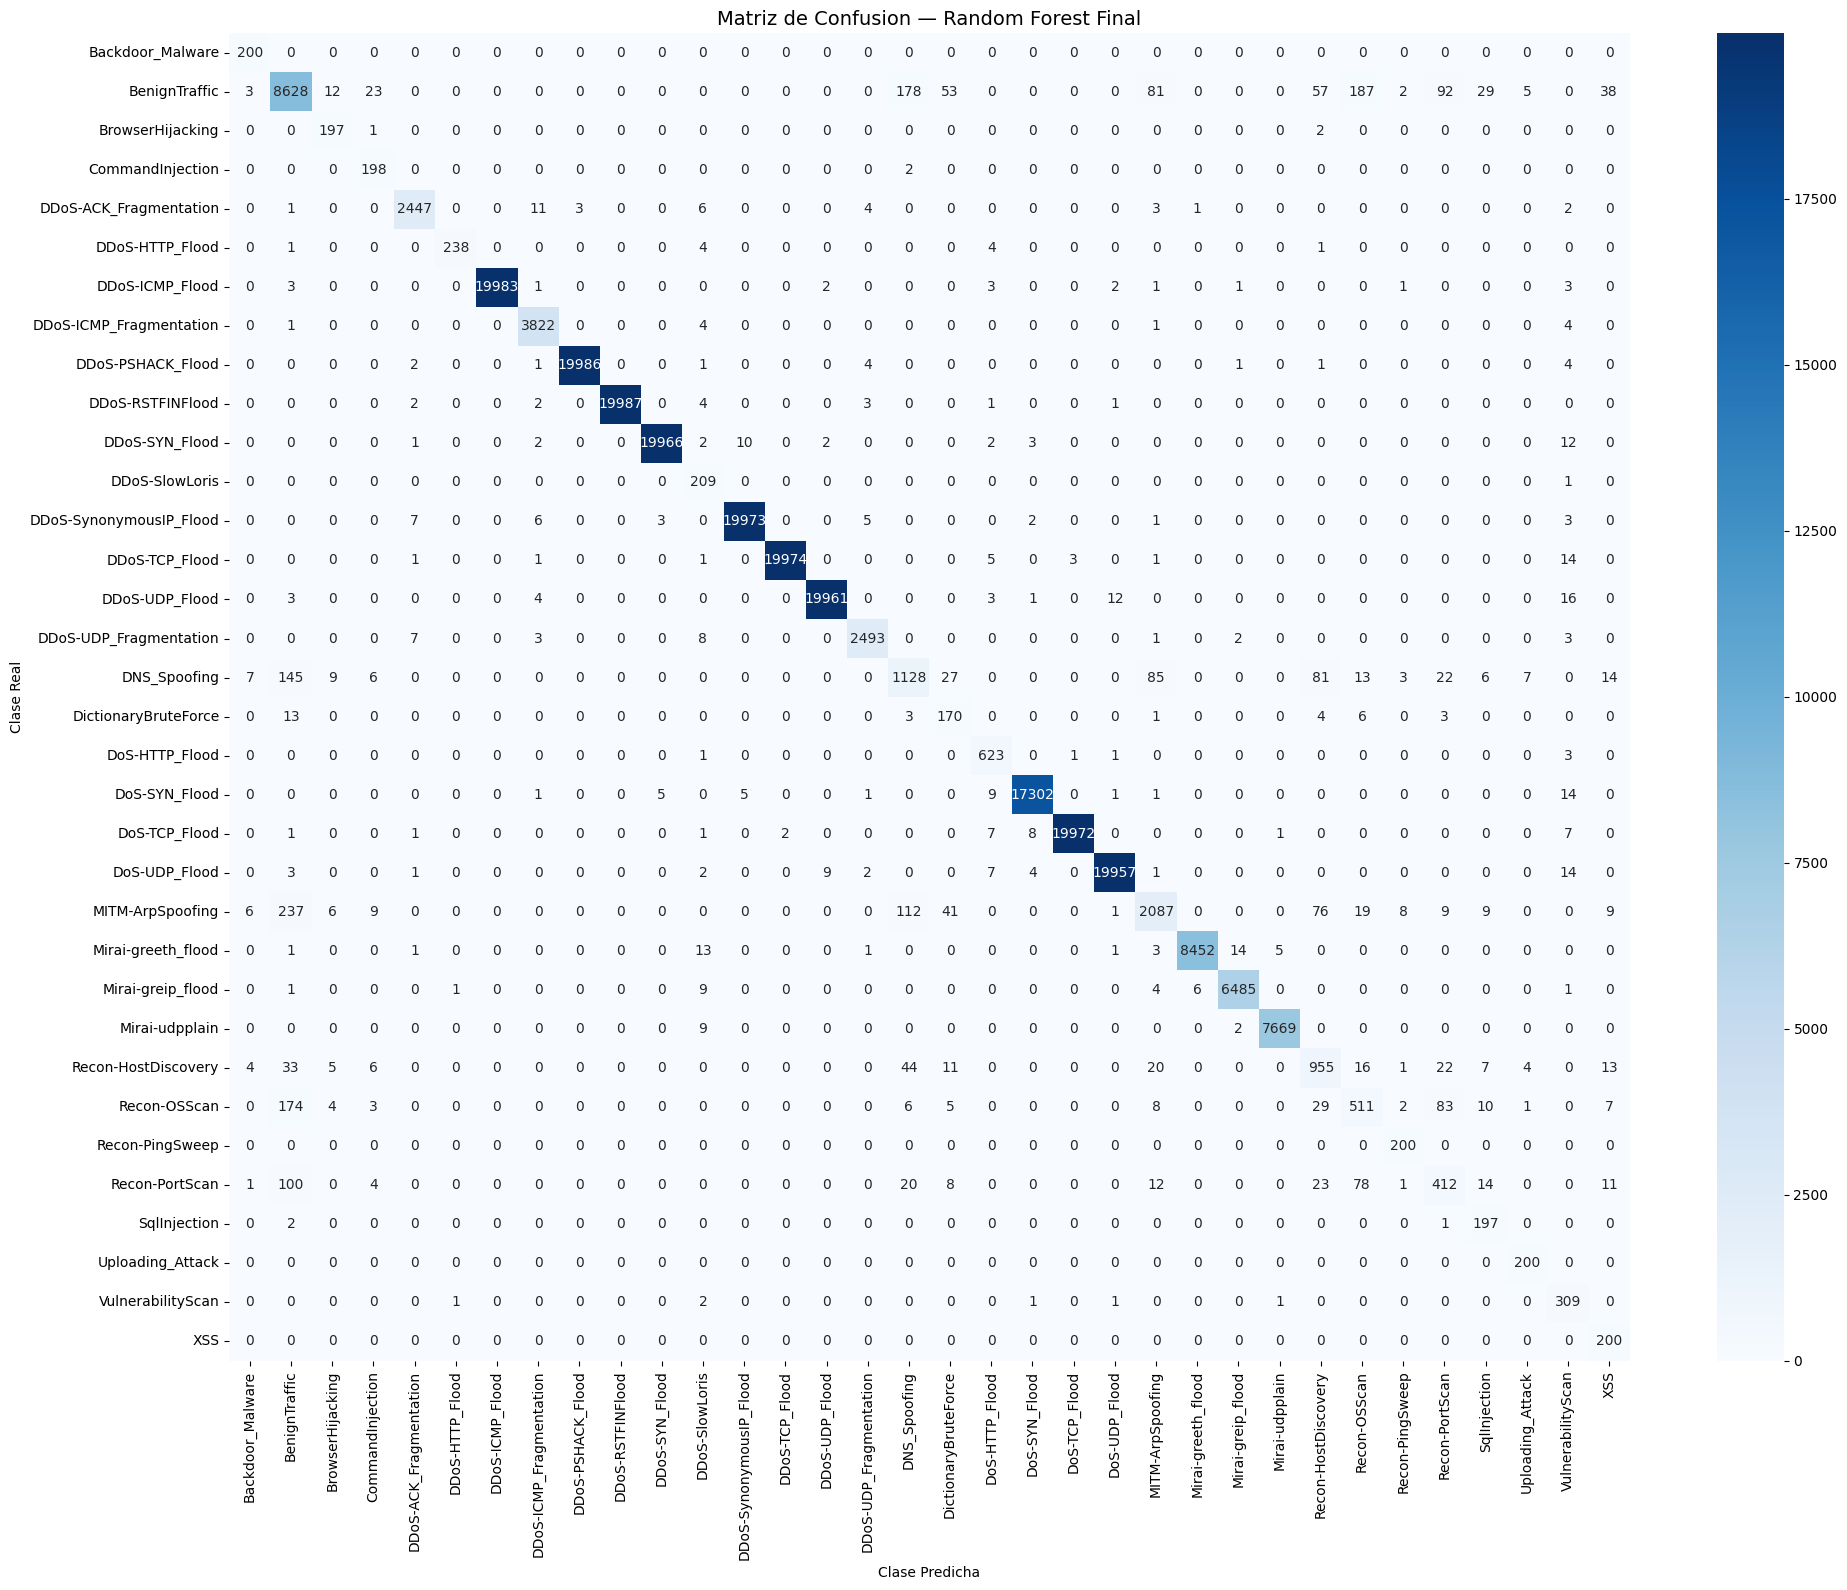

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Matriz de Confusion — Random Forest Final', fontsize=14)
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    2.9s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    9.2s finished


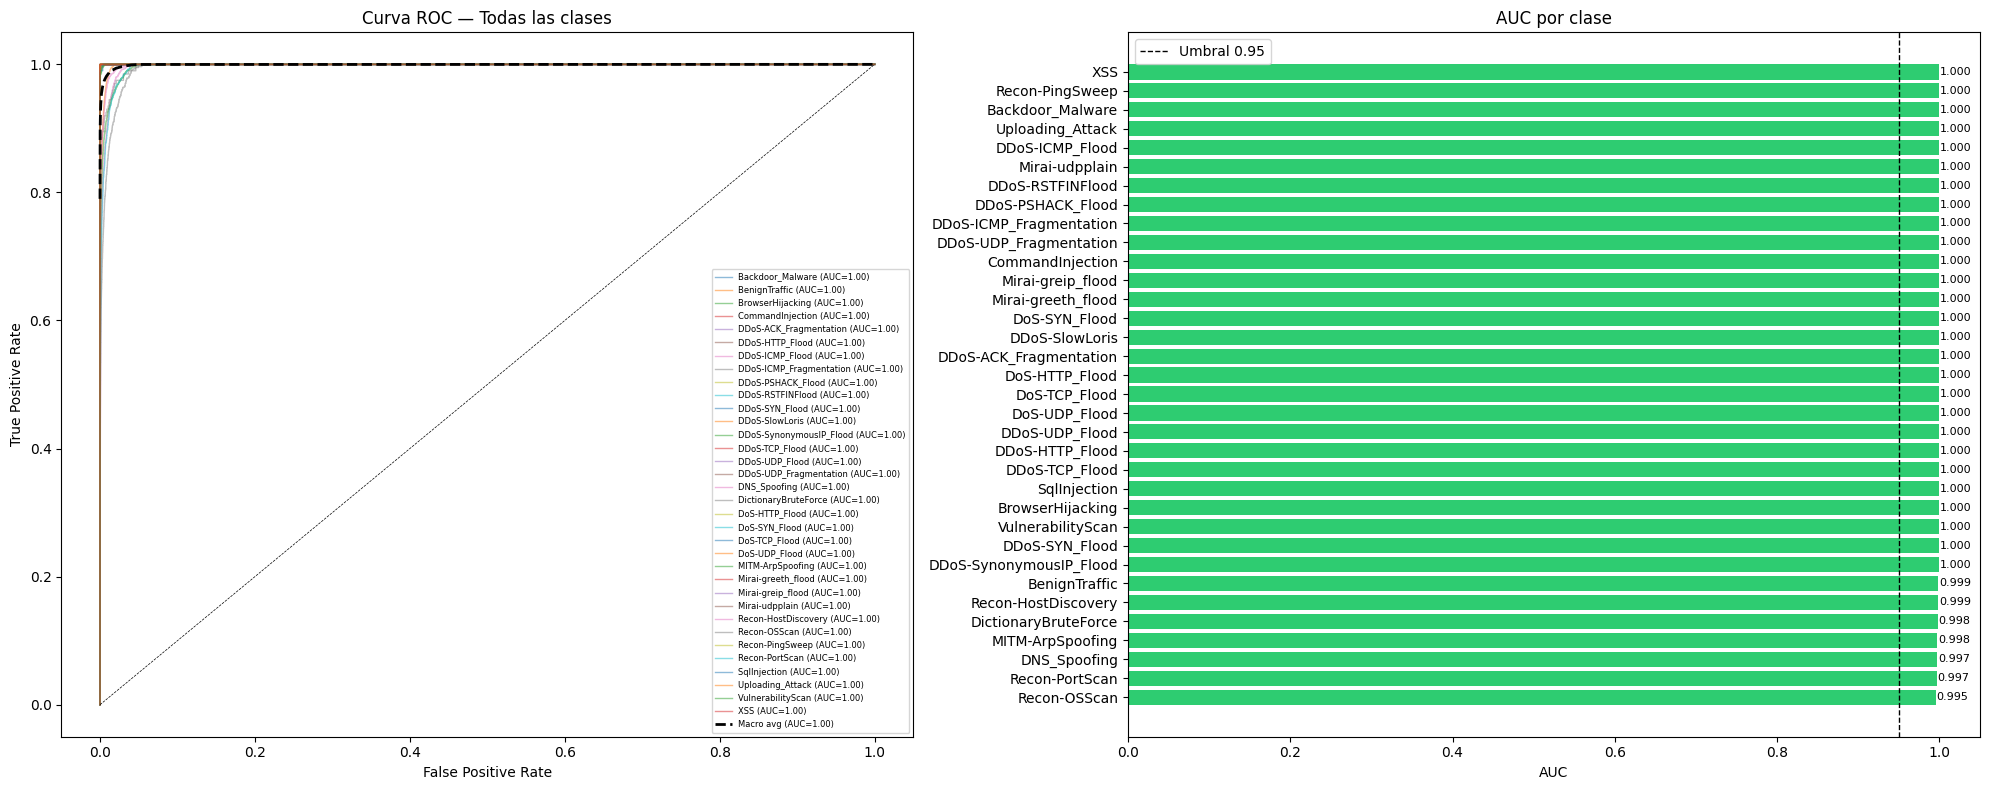

AUC Macro promedio: 0.9995


In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
y_prob = rf_final.predict_proba(X_test_sel)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(le.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr_macro = np.unique(np.concatenate([fpr[i] for i in range(len(le.classes_))]))
mean_tpr = np.zeros_like(fpr_macro)
for i in range(len(le.classes_)):
    mean_tpr += np.interp(fpr_macro, fpr[i], tpr[i])
mean_tpr /= len(le.classes_)
roc_auc_macro = auc(fpr_macro, mean_tpr)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for i in range(len(le.classes_)):
    axes[0].plot(fpr[i], tpr[i], lw=1, alpha=0.5, label=f'{le.classes_[i]} (AUC={roc_auc[i]:.2f})')
axes[0].plot(fpr_macro, mean_tpr, color='black', lw=2, linestyle='--', label=f'Macro avg (AUC={roc_auc_macro:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.5)
axes[0].set_title('Curva ROC — Todas las clases')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=6, loc='lower right')

auc_sorted = sorted(roc_auc.items(), key=lambda x: x[1])
clases_sorted = [le.classes_[i] for i, _ in auc_sorted]
auc_values = [v for _, v in auc_sorted]
colors = ['#e74c3c' if v < 0.95 else '#2ecc71' for v in auc_values]
axes[1].barh(clases_sorted, auc_values, color=colors)
axes[1].axvline(x=0.95, color='black', linestyle='--', lw=1, label='Umbral 0.95')
axes[1].set_title('AUC por clase')
axes[1].set_xlabel('AUC')
axes[1].legend()
for i, v in enumerate(auc_values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'AUC Macro promedio: {roc_auc_macro:.4f}')

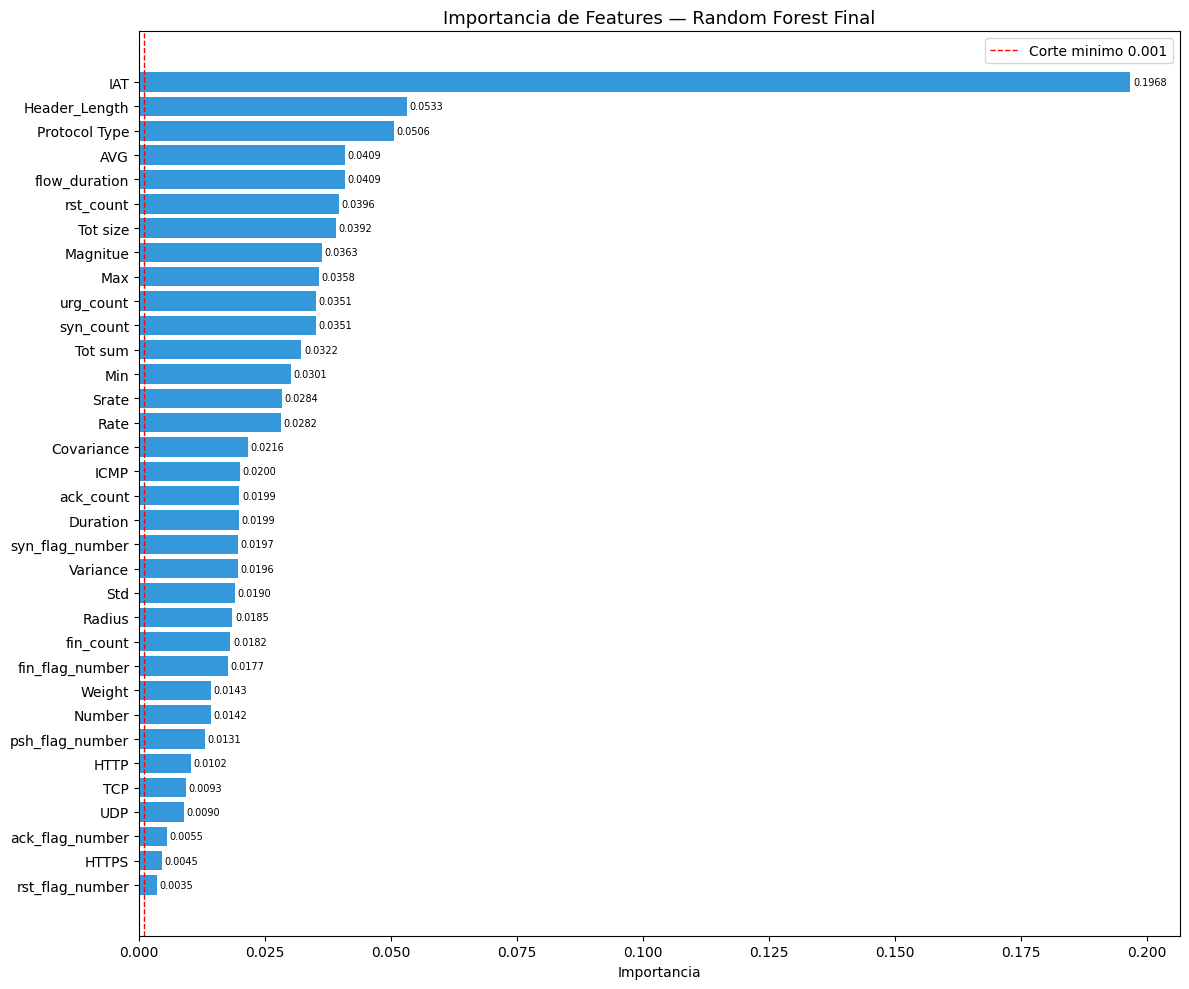

In [16]:
features_sel = np.load(f'{DRIVE_PATH}features_seleccionadas.npy', allow_pickle=True)

importancias = pd.DataFrame({
    'feature': features_sel,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(12, 10))
colors = ['#3498db' for _ in importancias['feature']]
plt.barh(importancias['feature'], importancias['importance'], color=colors)
plt.title('Importancia de Features — Random Forest Final', fontsize=13)
plt.xlabel('Importancia')
plt.axvline(x=0.001, color='red', linestyle='--', lw=1, label='Corte minimo 0.001')
plt.legend()
for i, (feat, val) in enumerate(zip(importancias['feature'], importancias['importance'])):
    plt.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=7)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}feature_importance_final.png', bbox_inches='tight', dpi=150)
plt.show()